In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_squared_error
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

In [52]:
data=load_diabetes()

In [53]:
x=data.data
y=data.target

In [54]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=45)

In [55]:
lr=LinearRegression()
lr.fit(x_train,y_train)
y_pred=lr.predict(x_test)

In [56]:
print("R2 Score: ",r2_score(y_test,y_pred))
print("RSME",np.sqrt(mean_squared_error(y_test,y_pred)))

R2 Score:  0.5188113124539249
RSME 48.72713760953252


Model training using ridge regression

In [59]:
rr=Ridge(alpha=0.0001)
rr.fit(x_train,y_train)
y_pred1=rr.predict(x_test)
print("R2 Score: ",r2_score(y_test,y_pred))
print("RSME",np.sqrt(mean_squared_error(y_test,y_pred1)))

R2 Score:  0.5188113124539249
RSME 48.718937001819555


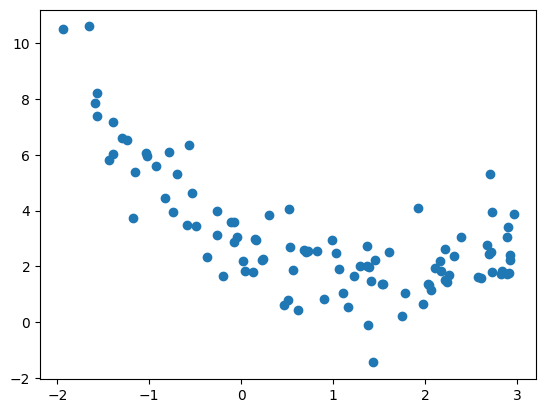

In [60]:
m=100
x1=5*np.random.rand(m,1)-2
x2=0.7*x1**2-2*x1+3+np.random.randn(m,1)
plt.scatter(x1,x2)
plt.show()

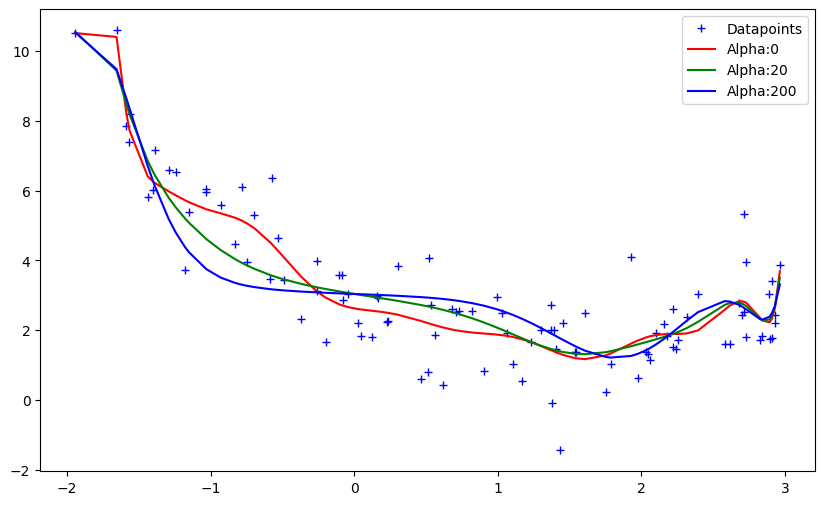

In [63]:
def get_preds_ridge(x1,x2,alpha):
    model=Pipeline([
        ('poly_feats',PolynomialFeatures(degree=16)),
        ('ridge',Ridge(alpha=alpha))
    ])
    model.fit(x1,x2)
    return model.predict(x1)
alphas=[0,20,200]
cs=['r','g','b']
plt.figure(figsize=(10,6))
plt.plot(x1,x2,'b+',label='Datapoints')

for alpha,c in zip(alphas,cs):
    preds=get_preds_ridge(x1,x2,alpha)
    plt.plot(sorted(x1[:,0]),preds[np.argsort(x1[:,0])],c,label='Alpha:{}'.format(alpha))
plt.legend()
plt.show()
